# Implement Markowitz model 

### Set up long positions using all wealth. Diversification of portfolio i.e combining multiple assets helps reduce unsystematic risk. Including low or non-correlated stocks, bonds, commodities, etc. in the portfolio helps minimize risk.  

### Show expected returns and volatility for different portfolions. Then perform portfolio optimization and find best portfolio using Sharpe ratio (Avg. return / Avg. volatility)
)


### $\mu_{portfolio}$ = E ($\sum_{i}$ w$_{i}$ r$_{i}$) = $\sum_{i}$ w$_{i}$ $\mu_{i}$ = w$^{T}$ $\cdot$ $\mu$ 

### $\sigma_{portfolio}$ = $\sum_{i}\sum_{j}$ w$_{i}$w$_{j}$ $\sigma_{ij}$ =  w$^{T}$ $\cdot$ $\Sigma$ $\cdot$ w 

where 

#### $\mu$ = Mean,  $\sigma$ = Variance, w = weights, r= returns, $\Sigma$ = Covariance matrix with elements $\sigma_{ij}$ = E( (r$_{i}$ - $\mu_{i}$) (r$_{j}$ - $\mu_{j}$) )

In [1]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as optimization

In [2]:
# on average there are 252 trading days in a year
NUM_TRADING_DAYS = 252
# we will generate random w (different portfolios)
NUM_PORTFOLIOS = 10000

In [9]:
# stocks we are going to handle
stocks = ['AAPL', 'WMT', 'TSLA', 'GE', 'AMZN', 'DB', 'NVDA', 'BZ=F']

# historical data - define START and END dates
start_date = '2014-01-01'
end_date = '2026-04-01'

In [10]:
def download_data():
    # name of the stock (key) - stock values (2012-2022) as the values
    stock_data = {}

    for stock in stocks:
        # closing prices
        ticker = yf.Ticker(stock)
        stock_data[stock] = ticker.history(start=start_date, end=end_date)['Close']

    return pd.DataFrame(stock_data)


def show_data(data):
    data.plot(figsize=(15, 8))
    plt.show()

### Visualize the stock closing prices from 01 Jan 2014 to 01 Apr 2026

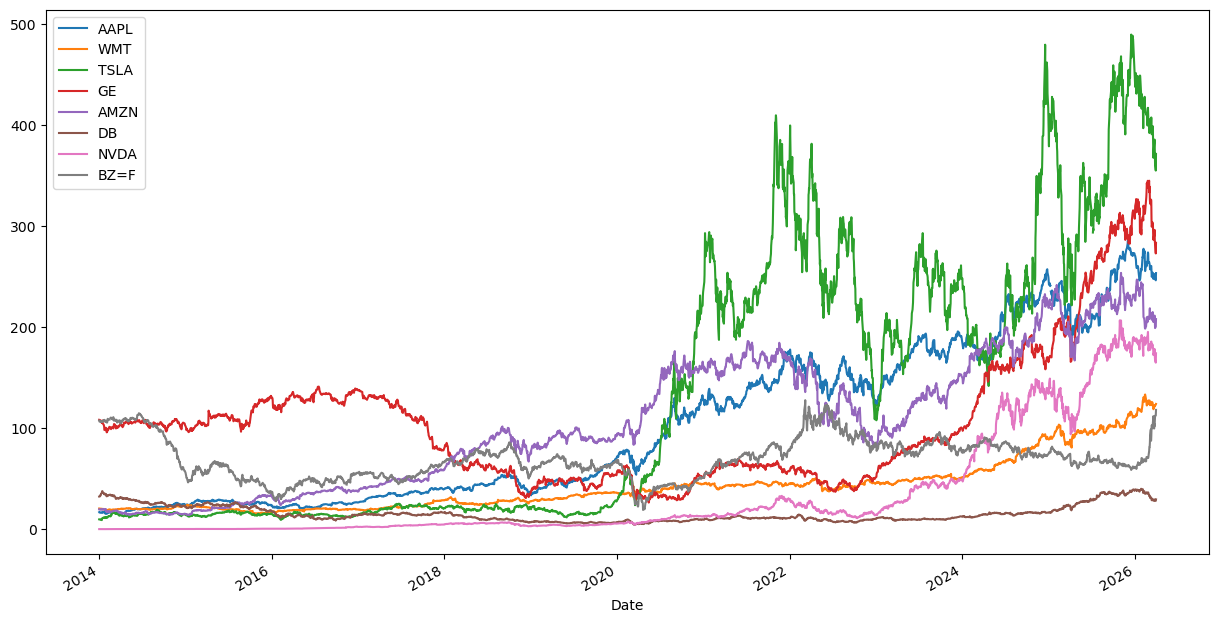

In [11]:
dataset = download_data()
show_data(dataset)

In [12]:
def calculate_return(data):
    # NORMALIZATION - to measure all variables in comparable metric
    log_return = np.log(data / data.shift(1))
    return log_return[1:]


def show_statistics(returns):
    # instead of daily metrics we are after annual metrics
    # mean of annual return
    display(returns.mean() * NUM_TRADING_DAYS)
    display(returns.cov() * NUM_TRADING_DAYS)

def show_mean_variance(returns, weights):
    # we are after the annual return
    portfolio_return = np.sum(returns.mean() * weights) * NUM_TRADING_DAYS
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov()
                                                            * NUM_TRADING_DAYS, weights)))
    print("Expected portfolio mean (return): ", portfolio_return)
    print("Expected portfolio volatility (standard deviation): ", portfolio_volatility)

### Show the log daily returns for the assets in the portfolio (in %)

In [14]:
log_daily_returns = calculate_return(dataset)
log_daily_returns

,AAPL,WMT,TSLA,GE,AMZN,DB,NVDA,BZ=F
Date,,,,,,,,
2014-01-03 00:00:00-05:00,-0.022211,-0.003300,-0.003604,-0.000728,-0.003852,0.002782,-0.012053,-0.008292
2014-01-06 00:00:00-05:00,0.005439,-0.005610,-0.017265,-0.008038,-0.007113,0.007028,0.013313,-0.001498
2014-01-07 00:00:00-05:00,-0.007178,0.003064,0.015927,0.001100,0.011116,0.022661,0.016240,0.005792
2014-01-08 00:00:00-05:00,0.006313,-0.007935,0.012773,-0.002936,0.009726,0.024186,0.013538,-0.001865
2014-01-09 00:00:00-05:00,-0.012852,0.003335,-0.025101,0.000367,-0.002267,-0.001621,-0.037999,-0.007118
...,...,...,...,...,...,...,...,...
2026-03-25 00:00:00-04:00,0.003887,0.008241,0.007595,0.020199,0.021340,0.026586,0.019668,-0.021964
2026-03-26 00:00:00-04:00,0.001068,-0.007177,-0.036518,-0.038919,-0.019893,-0.025551,-0.042530,0.055096
2026-03-27 00:00:00-04:00,-0.016305,0.005794,-0.028015,-0.008556,-0.040312,-0.021274,-0.021963,0.041351


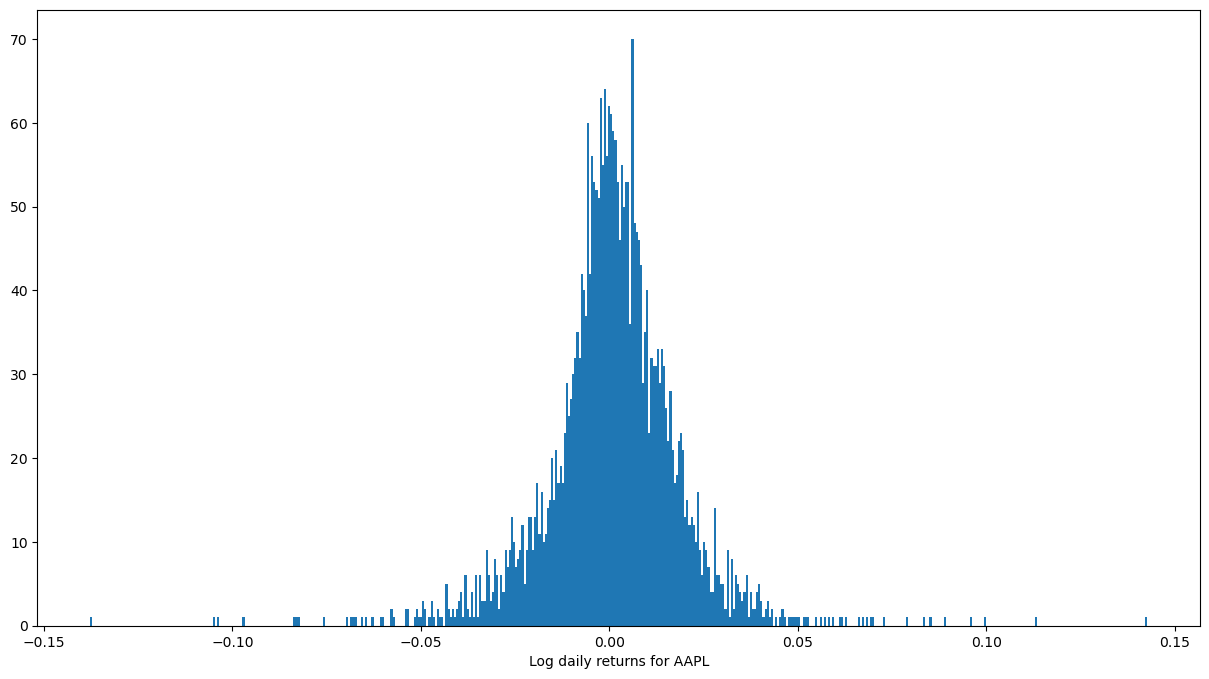

In [15]:
fig = plt.figure(figsize=(15,8))
plt.hist(log_daily_returns['AAPL'],bins=500)
plt.xlabel('Log daily returns for AAPL')
plt.show()

In [16]:
show_statistics(log_daily_returns)

AAPL    0.224832
WMT     0.144011
TSLA    0.301622
GE      0.078348
AMZN    0.193584
DB     -0.007584
NVDA    0.508271
BZ=F    0.007256
dtype: float64

,AAPL,WMT,TSLA,GE,AMZN,DB,NVDA,BZ=F
AAPL,0.079666,0.018422,0.067297,0.032295,0.049069,0.036025,0.068414,0.016800
WMT,0.018422,0.044234,0.019683,0.013224,0.016747,0.013348,0.019452,0.004021
TSLA,0.067297,0.019683,0.319090,0.047554,0.075073,0.055058,0.110034,0.028894
GE,0.032295,0.013224,0.047554,0.112445,0.029410,0.057129,0.051416,0.025104
AMZN,0.049069,0.016747,0.075073,0.029410,0.107642,0.035874,0.077584,0.014279
DB,0.036025,0.013348,0.055058,0.057129,0.035874,0.152585,0.057191,0.027850
NVDA,0.068414,0.019452,0.110034,0.051416,0.077584,0.057191,0.218040,0.021950
BZ=F,0.016800,0.004021,0.028894,0.025104,0.014279,0.027850,0.021950,0.152476


### Show annual expected returns and covariance matrix for an example portfolio with weights [0.1,0.1,0.3,0.2,0.2,0.1, 0.15, 0.05]  (in %)

In [17]:
show_mean_variance(log_daily_returns,np.array([0.1,0.1,0.3,0.2,0.2,0.1, 0.15, 0.05] ))

Expected portfolio mean (return):  0.25760220383417914
Expected portfolio volatility (standard deviation):  0.3242814946978829


In [18]:
def generate_portfolios(returns):
    portfolio_means = []
    portfolio_risks = []
    portfolio_weights = []

    for _ in range(NUM_PORTFOLIOS):
        w = np.random.random(len(stocks))
        w /= np.sum(w)
        portfolio_weights.append(w)
        portfolio_means.append(np.sum(returns.mean() * w) * NUM_TRADING_DAYS)
        portfolio_risks.append(np.sqrt(np.dot(w.T, np.dot(returns.cov()
                                                          * NUM_TRADING_DAYS, w))))

    return np.array(portfolio_weights), np.array(portfolio_means), np.array(portfolio_risks)

def show_portfolios(returns, volatilities):
    plt.figure(figsize=(15, 8))
    plt.scatter(volatilities, returns, c=returns / volatilities, marker='o')
    plt.grid(True)
    plt.xlabel('Expected Volatility')
    plt.ylabel('Expected Return')
    plt.colorbar(label='Sharpe Ratio')
    plt.show()

### Show portfolios along with expected returns and volatility 

#### Yellow indicates efficient frontier

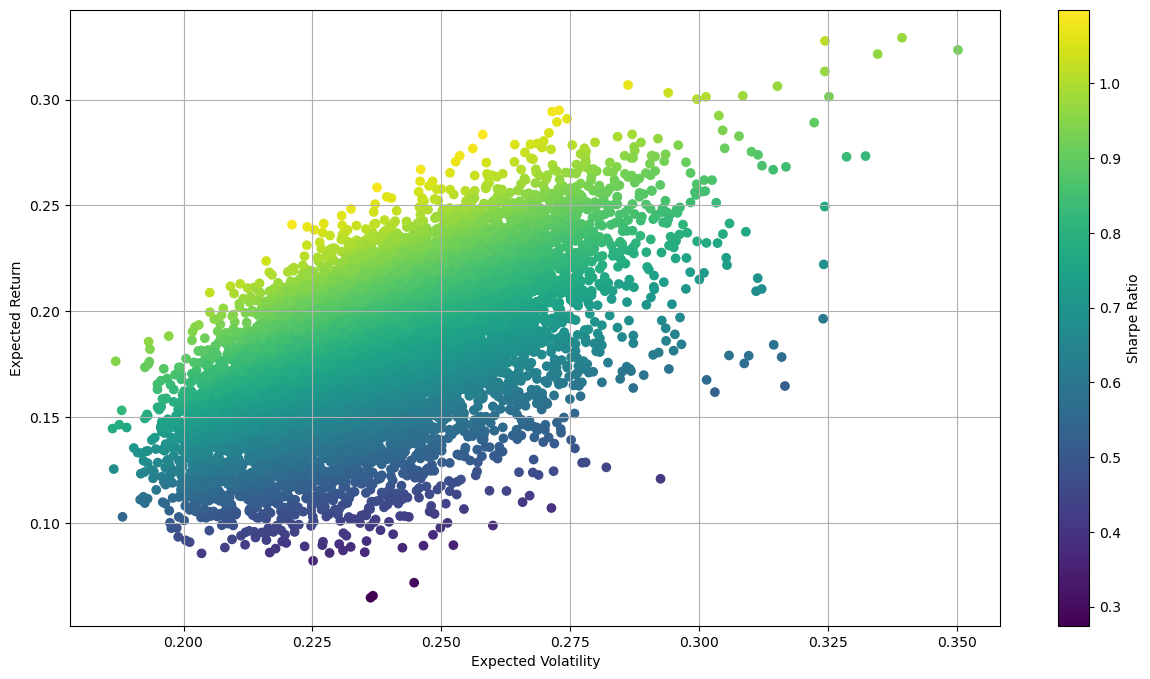

In [19]:
pweights, means, risks = generate_portfolios(log_daily_returns)
show_portfolios(means, risks)

In [20]:
def statistics(weights, returns):
    portfolio_return = np.sum(returns.mean() * weights) * NUM_TRADING_DAYS
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov()
                                                            * NUM_TRADING_DAYS, weights)))
    return np.array([portfolio_return, portfolio_volatility,
                     portfolio_return / portfolio_volatility])


# scipy optimize module can find the minimum of a given function
# the maximum of a f(x) is the minimum of -f(x)
def min_function_sharpe(weights, returns):
    return -statistics(weights, returns)[2]


# what are the constraints? The sum of weights = 1 !!!
# f(x)=0 this is the function to minimize
def optimize_portfolio(weights, returns):
    # the sum of weights is 1
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    # the weights can be 1 at most: 1 when 100% of money is invested into a single stock
    bounds = tuple((0, 1) for _ in range(len(stocks)))
    return optimization.minimize(fun=min_function_sharpe, x0=weights[0], args=returns
                                 , method='SLSQP', bounds=bounds, constraints=constraints)


def print_optimal_portfolio(optimum, returns):
    print("Optimal portfolio: ", optimum['x'].round(3))
    print("Expected return, volatility and Sharpe ratio: ",
          statistics(optimum['x'].round(3), returns))


def show_optimal_portfolio(opt, rets, portfolio_rets, portfolio_vols):
    plt.figure(figsize=(15, 8))
    plt.scatter(portfolio_vols, portfolio_rets, c=portfolio_rets / portfolio_vols, marker='o')
    plt.grid(True)
    plt.xlabel('Expected Volatility')
    plt.ylabel('Expected Return')
    plt.colorbar(label='Sharpe Ratio')
    plt.plot(statistics(opt['x'], rets)[1], statistics(opt['x'], rets)[0], 'g*', markersize=20.0)
    plt.show()

Optimal portfolio:  [0.141 0.45  0.002 0.    0.    0.    0.407 0.   ]
Expected return, volatility and Sharpe ratio:  [0.30397561 0.25343281 1.19943274]


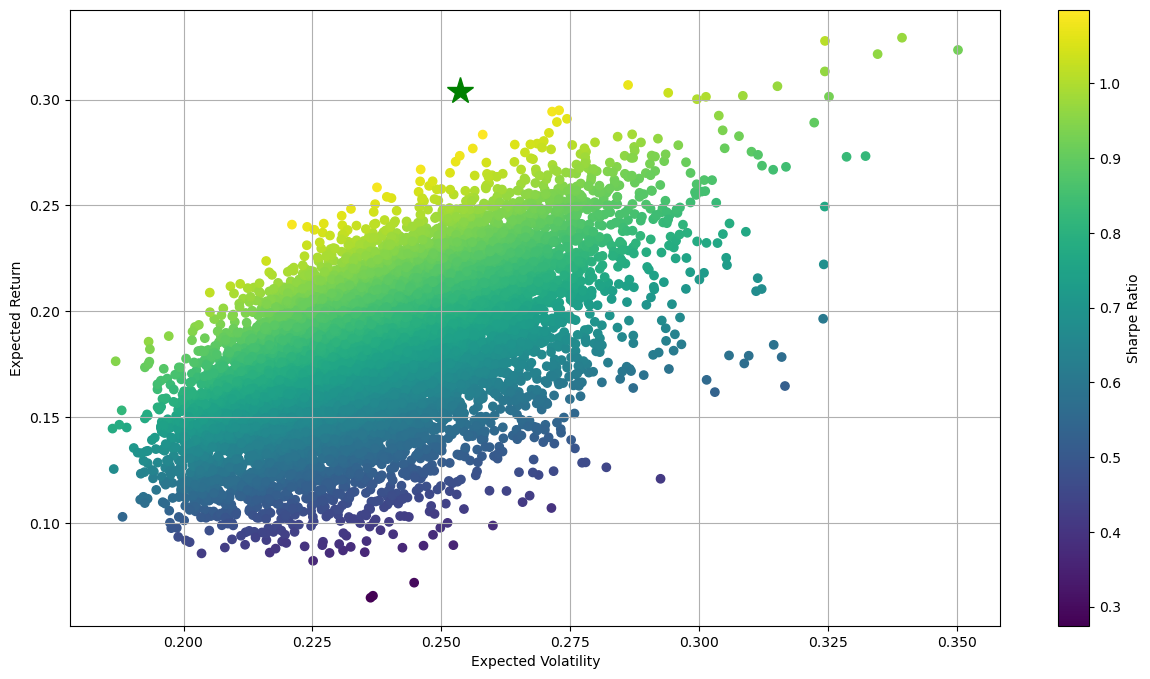

In [21]:
optimum = optimize_portfolio(pweights, log_daily_returns)
print_optimal_portfolio(optimum, log_daily_returns)
show_optimal_portfolio(optimum, log_daily_returns, means, risks)